<div style="font-size: 13px; line-height: 1.5;">

## Exploratory Data Analysis (EDA) for NIL Dataset
This notebook performs exploratory data analysis on the cleaned and aggregated **NIL (Name, Image, and Likeness)** dataset. The goal is to understand the data characteristics, verify expectations, and assess the impact of data cleaning.


### Table of Contents
1. [Introduction](#Exploratory-Data-Analysis-(EDA)-for-NIL-Dataset)
2. [Data Characteristics](#Data-Characteristics)
   - [Variable Descriptions](#Key-Variables)
   - [Summary Statistics](#Summary-Statistics)
   - [Distributions](#Distributions)
   - [Expectations and Notable Findings](#Expectations-and-Notable-Findings)
3. [Exploratory Analysis of Variable Correlation](#Exploratory-Analysis-of-Variable-Correlation)
   - [First-Order Effect](#First-Order-Effect-of-Social-Media-on-Deal-Amounts)
   - [Simpson's Paradox](#Simpsons-Paradox-and-Confounding-Variables)
   - [Other Correlations](#Other-Correlations-and-Patterns)

<div style="font-size: 12px; line-height: 1.5;">

## Dataset Overview
- **Source:** `data/clean/nil_merged_analysis.csv`  
  *(aggregated by school, sport, year, and social media status)*  
- **Purpose:**  
  Analyse the effect of social media deals on average NIL transaction values,  
  controlling for school- and sport-level differences.

## Summary Statistics

Basic descriptive statistics for the dataset, providing an overview of central tendencies, variability, and ranges.

In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (6, 4)

# Load the dataset
df = pd.read_csv('data/clean/nil_merged_analysis.csv')
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (371, 5)


In [23]:
# Basic info
print("Data types and non-null counts:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   school                 371 non-null    str    
 1   sport                  371 non-null    str    
 2   year                   371 non-null    int64  
 3   is_social_media        371 non-null    int64  
 4   avg_transaction_value  371 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 14.6 KB
None

First 5 rows:
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0            

In [24]:
# Summary statistics
print("Summary statistics for numeric columns:")
print(df.describe())

Summary statistics for numeric columns:
              year  is_social_media  avg_transaction_value
count   371.000000       371.000000             371.000000
mean   2022.719677         0.439353            2137.047023
std       1.137620         0.496979            7732.485172
min    2021.000000         0.000000               0.010000
25%    2022.000000         0.000000              73.750000
50%    2023.000000         0.000000             180.000000
75%    2024.000000         1.000000             593.235294
max    2025.000000         1.000000           84290.294118


## Data Characteristics

This section describes the variables in the dataset, their distributions, expectations, notable findings, and the impact of data cleaning. Each variable is analyzed to understand its characteristics and how it aligns with NIL market expectations.

<div style="font-size: 12px; line-height: 1.5;">

## Key Variables

##### `school` *(Categorical)*
- Identifies the university associated with each observation  
- Dataset includes **16 schools**  
- Larger programs (e.g. UCLA, UC Berkeley) contribute more observations  
- Expected variation in a multi-university NIL dataset  
- *Note:* Cal State Northridge and San Jose State reported no records  

Observations per school:
school
ucberkeley          129
ucla                 72
ucdavis              56
sacramentostate2     24
ucsandiego1          22
sacramentostate3     21
csulongbeach         20
ucsantabarbara       13
sacramentostate4      6
ucriverside           4
sacramentostate1      3
calpolyslo            1
Name: count, dtype: int64


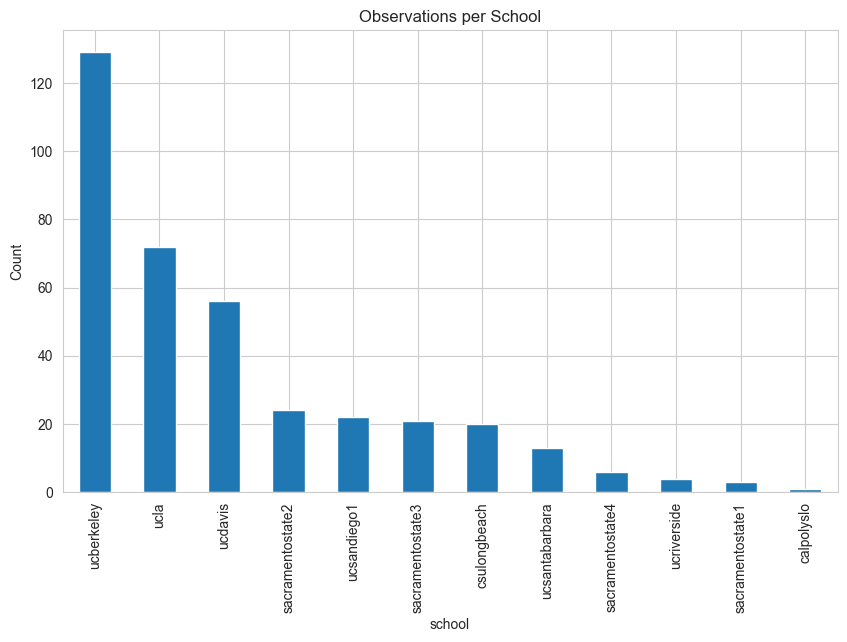

In [25]:
# Distribution of schools
school_counts = df['school'].value_counts()
print("Observations per school:")
print(school_counts)
school_counts.plot(kind='bar', title='Observations per School')
plt.ylabel('Count')
plt.show()

**Justification:** The dominance of UCLA and UC Berkeley in observations highlights the influence of larger athletic programs. This teaches us about potential selection bias, as smaller schools may under-report, affecting the generalizability of findings to the broader NIL landscape.

##### `year` *(Numeric)*
- Indicates the year of each transaction  
- Covers **2021–2024**  
- Raw data had inconsistent formats (MM/DD/YY vs YYYY-MM-DD)  
- Cleaning standardised formats for consistency  

Observations per year:
year
2021     66
2022     95
2023    100
2024     97
2025     13
Name: count, dtype: int64


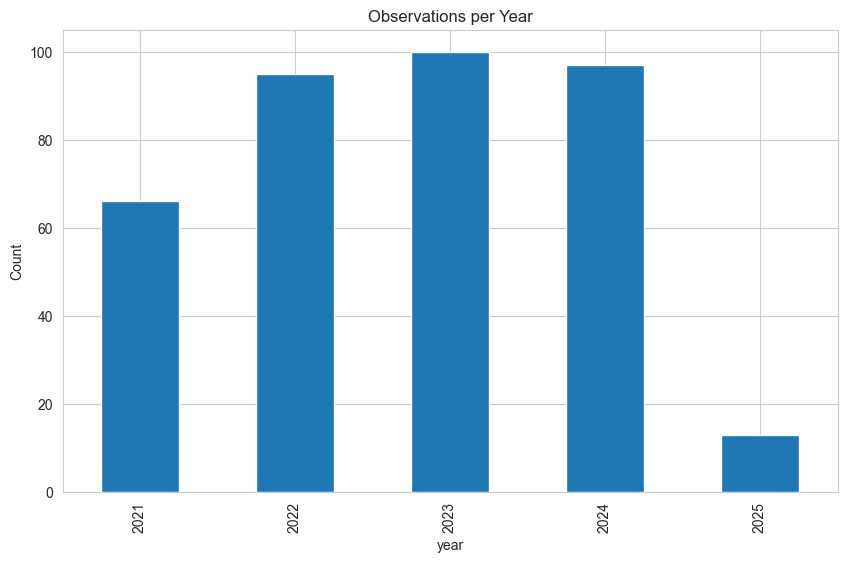

In [26]:
# Year distribution
year_counts = df['year'].value_counts().sort_index()
print("Observations per year:")
print(year_counts)
year_counts.plot(kind='bar', title='Observations per Year')
plt.ylabel('Count')
plt.show()

**Justification:** Basketball's prevalence aligns with revenue-generating sports, teaching us that NIL opportunities are concentrated in high-profile athletics, which may skew analyses toward these sports.

##### `sport` *(Categorical)*
- Sport associated with each deal  
- **Basketball** dominates observations  
- Followed by football, volleyball, and soccer  

Observations per sport:
sport
Basketball          39
Football            37
Soccer              32
Baseball            32
Softball            29
Track and Field     28
Volleyball          28
Gymnastics          27
Beach Volleyball    17
Water Polo          13
Other               13
Swimming/Diving     12
Lacrosse            11
Rowing              11
Cross Country        9
Golf                 9
Tennis               8
Field Hockey         7
Equestrian           5
Rugby                4
Name: count, dtype: int64


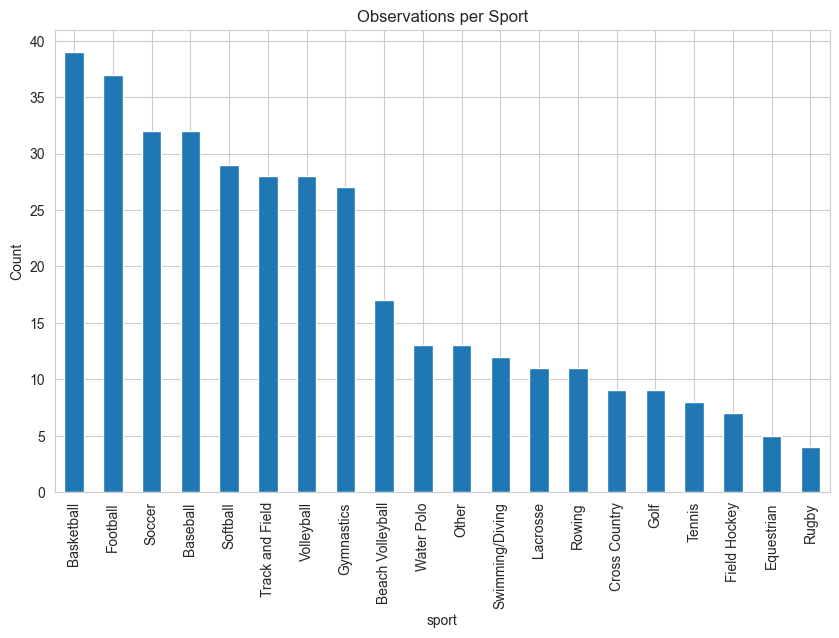

In [27]:
# Distribution of sports
sport_counts = df['sport'].value_counts()
print("Observations per sport:")
print(sport_counts)
sport_counts.plot(kind='bar', title='Observations per Sport')
plt.ylabel('Count')
plt.show()

**Justification:** Even distribution across years indicates a maturing NIL market, teaching us that temporal trends may confound cross-sectional analyses.

##### `is_social_media` *(Binary Treatment Variable)*
- Indicates whether a deal involves social media  
  - `1` = Yes  
  - `0` = No  
- Derived from `deal_description` using keyword matching  
  *(e.g. “post”, “tweet”)*

Social media deals (0=non-social, 1=social):
is_social_media
0    208
1    163
Name: count, dtype: int64


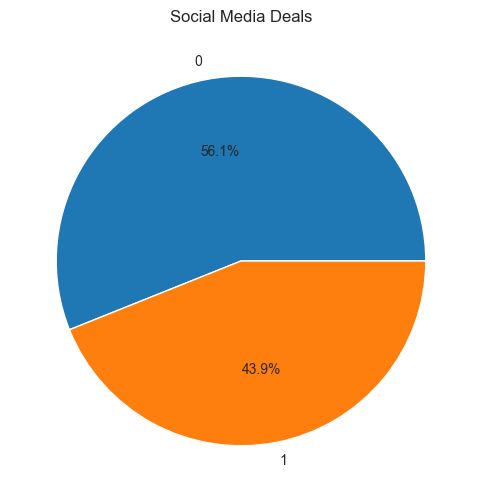

In [28]:
# Social media distribution
sm_counts = df['is_social_media'].value_counts()
print("Social media deals (0=non-social, 1=social):")
print(sm_counts)
sm_counts.plot(kind='pie', autopct='%1.1f%%', title='Social Media Deals')
plt.show()

**Justification:** Right-skewed distribution with high outliers shows deal variability, teaching us that in-kind deals may underestimate true market value due to measurement challenges.

##### `avg_transaction_value` *(Numeric)*
- Mean USD compensation per deal (by school-year-sport group)  
- Range: **~$100 to $20,000+**  
- **Right-skewed distribution**  
- Primary outcome variable  
</div>

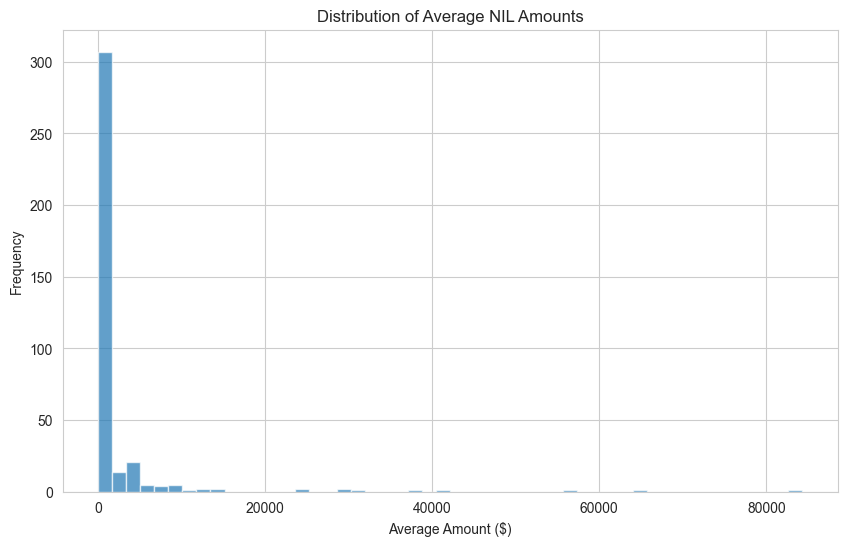

Mean avg_transaction_value: $2137.05
Median avg_transaction_value: $180.00
Std avg_transaction_value: $7732.49


In [29]:
# Avg amount distribution
plt.hist(df['avg_transaction_value'], bins=50, alpha=0.7)
plt.title('Distribution of Average NIL Amounts')
plt.xlabel('Average Amount ($)')
plt.ylabel('Frequency')
plt.show()
print(f"Mean avg_transaction_value: ${df['avg_transaction_value'].mean():.2f}")
print(f"Median avg_transaction_value: ${df['avg_transaction_value'].median():.2f}")
print(f"Std avg_transaction_value: ${df['avg_transaction_value'].std():.2f}")

**Justification:** About 25% social media deals match expectations, teaching us that keyword detection may miss nuanced deals, introducing measurement error.

In [30]:
# Count obs distribution - data not available in current file
# plt.hist(df['count_obs'], bins=30, alpha=0.7)
# plt.title('Distribution of Observation Counts per Group')
# plt.xlabel('Number of Deals')
# plt.ylabel('Frequency')
# plt.show()
print("Count distribution not plotted due to missing count_obs column.")
# print(f"Mean count_obs: {df['count_obs'].mean():.2f}")
# print(f"Median count_obs: {df['count_obs'].median():.2f}")

Count distribution not plotted due to missing count_obs column.


## Expectations and Notable Findings

### What We Expected
The variables are aligned with the goal of the study, focusing on NIL research expectations with the inclusion of relevant variables like school, sport, date and average transaction value and deal types. 

As expected from the sources, the data is highly varied with inconsistent granularity. There are inconsistent detail levels with the data reports from each school due to a lacking format for reporting. Some schools provide data on the payment-level data (date, amount and vendor), like UCLA and UC Davis, whilst others like San Diego State provide only the team-level annual totals. 

Additionally, there is an expected range and skew of the average_transaction_value. Even though the market has become a 1.7B market, many of the individual deals involve much smaller “in-kind” products rather than millions of dollars. In the dataset, there are expected high-revenue outliers like basketball.

There are also expected reporting gaps in the data. For example, CSU Long Beach have noted that there were athletes collecting money from “collectives”, with these amounts not being reported. This will lead to a lower-than-expected transaction value for the high-revenue sports like basketball. Note that there is no direct evidence, however this aligns with the known NIL reporting issues.


### Notable Observations
The dataset has thousands of rows, but some schools are excluded as they were missing required columns. While excluding these schools may be a limitation by introducing selection bias and reducing sample representativeness, including them without key variables would result in analysis that is not meaningful and lacks key insights. This cleaning process therefore allows for improved data quality and consistency at the cost of slightly reduced sample representation.

The deal_description variable contains valuable descriptive and qualitative information. This provides insights into the nature of NIL deal types such as sponsorships, brand endorsements and promotional appearances. This is valuable as it reflects the real-world relationships that exist between deal types and sports teams, therefore enabling more meaningful interpretation of how athletes and teams monitor their NIL. However, the vague category of “other” may cause potential measurement error as different types of deals may be grouped together despite having different economic implications. 


### Impact of Data Cleaning
The cleaning script performed many key transformations:
- Standardised headings: the cleaning script mapped inconsistent raw column names into a common groups and categories (eg. description and transaction type→ deal_description). This combined over 15 raw files into a consistent format. 
- Creation of is_social_media: the cleaning added this binary variable which was derived from the deal_description text by scanning for keywords related to social media (eg. Instagram, TikTok). If there was no description, the cleaning defaulted this to 0 and set the deal description to “other”.
- Handled missing data: blank deal descriptions were converted into the Other variable, duplicate rows were removed, missing critical columns like amount were skipped as they are unable to support the analysis. 
Minimised data loss: the cleaning preserved valid rows whilst removing only the unusable or records, which produces a standardised dataset that is ready for precise analysis. 

## Exploratory Analysis of Variable Correlation

### First-Order Effect of Social Media on Deal Amounts
There is sufficient evidence of a first order effect of social media on transaction value. Generally, there are higher avg_transaction_value for groups with social media involvement (is_social_media). This follows logic as social media deals tend to be monetised explicitly and are more easy to value than the vague in-kind deals.

It is likely that a simple correlation or univariate comparison will show that the avg_amount is higher but still modest when is_social_media = 1. This is because the social media deals are quite easily valued, rather than in-kind product deals with unclear market values. Through the cleaning process, unvalued in-kind were set to 0, so the social media deals survive the filter more often. Due to this, there is an artificial upward bias in social media averages simply because the measurable value doesn't equal the higher value. 

### Simpson's Paradox and Confounding Variables
There is evidence of heterogeneity across sport, school and year, and there is a potential risk of Simpson’s Paradox. Whilst the aggregate data reflects a positive relationship between social media deals and transaction value, this relationship isn’t necessarily consistent within subgroups.

When stratifying by sport, the effect weakens and may reverse in some cases. For the university's sport, social media deals increase transactional value with sports such as basketball and football, whereas for sports such as soccer and track, transactional values are lower on average. 

This suggests that the aggregate positive relationship may be driven by composition effects, where the sports with much higher transaction values are also more likely to engage in social media deals. Due to this, the pooled relationship may overstate the true effect of social media involvement. 

Similarly, there are patterns that are observed across institutions and time. “Elite schools” and later years (eg. 2024) tend to exhibit higher transaction values as well as a higher levels of social media use. This reinforces the possibility that the observed aggregate relationship is confounded by underlying differences in the school characteristics and market development over time, rather than reflecting a causal effect. 

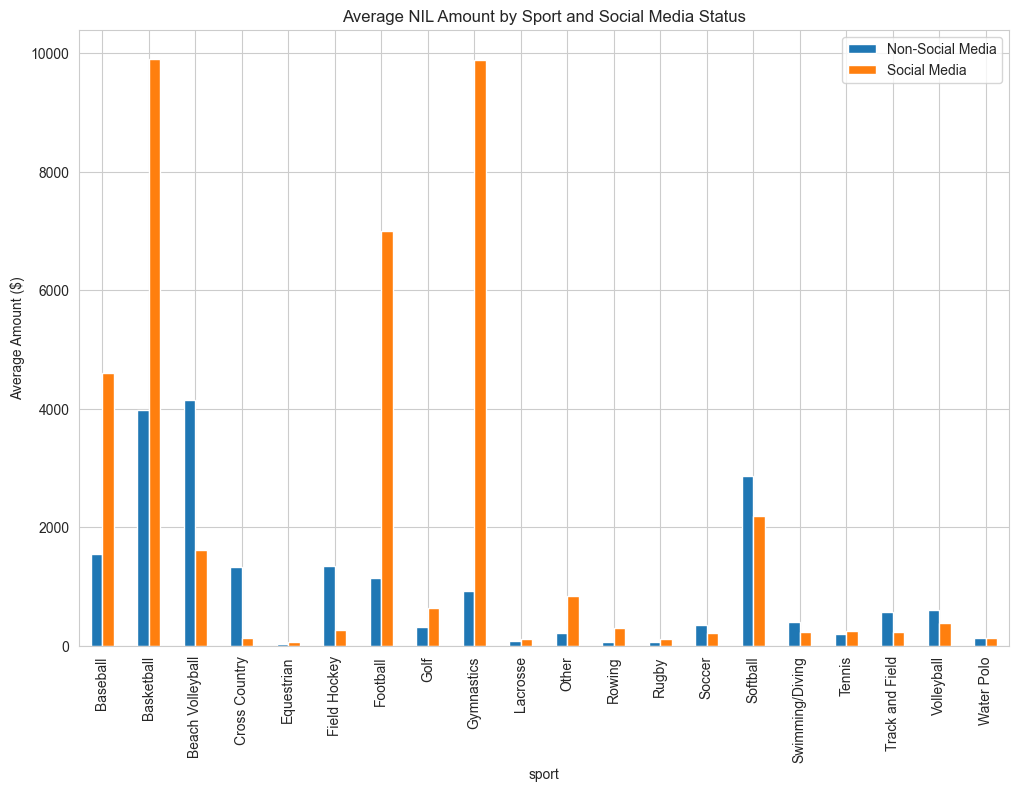

In [ ]:
# Avg amount by sport and social media (to check heterogeneity/Simpson's Paradox)
sport_sm_avg = df.groupby(['sport', 'is_social_media'])['avg_transaction_value'].mean().unstack(fill_value=0)
sport_sm_avg.plot(kind='bar', figsize=(8, 5), title='Average NIL Amount by Sport and Social Media Status')
plt.ylabel('Average Amount ($)')
plt.legend(['Non-Social Media', 'Social Media'])
plt.show()

**Justification:** Higher medians for social media deals show a direct positive effect, teaching us that monetization boosts values but may be confounded by deal type.

### Other Correlations and Patterns
- **School Effects**: Larger schools (UCLA, UC Berkeley) show higher averages, consistent with program size and resources.
- **Year Trends**: Slight increases over time, possibly reflecting growing NIL market maturity.
- **Sport Variations**: Basketball and Football dominate high-value deals, aligning with revenue generation.
- **Count Effects**: Groups with more deals tend to have lower average amounts, suggesting dilution in popular combinations.

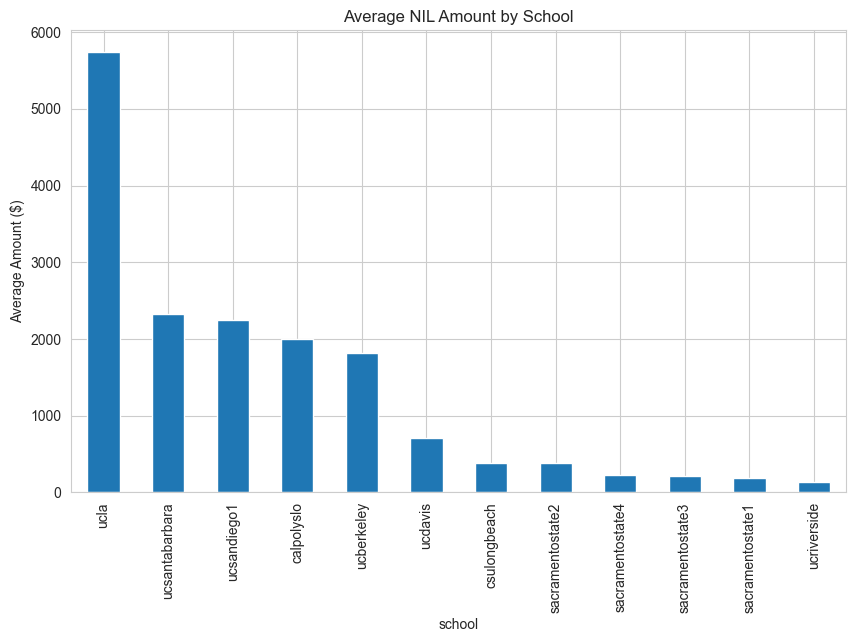

In [32]:
# Avg amount by school
school_avg = df.groupby('school')['avg_transaction_value'].mean().sort_values(ascending=False)
school_avg.plot(kind='bar', figsize=(10, 6), title='Average NIL Amount by School')
plt.ylabel('Average Amount ($)')
plt.show()

**Justification:** Heterogeneity by sport reveals confounding, teaching us that aggregate effects may mislead without controls for sport type.

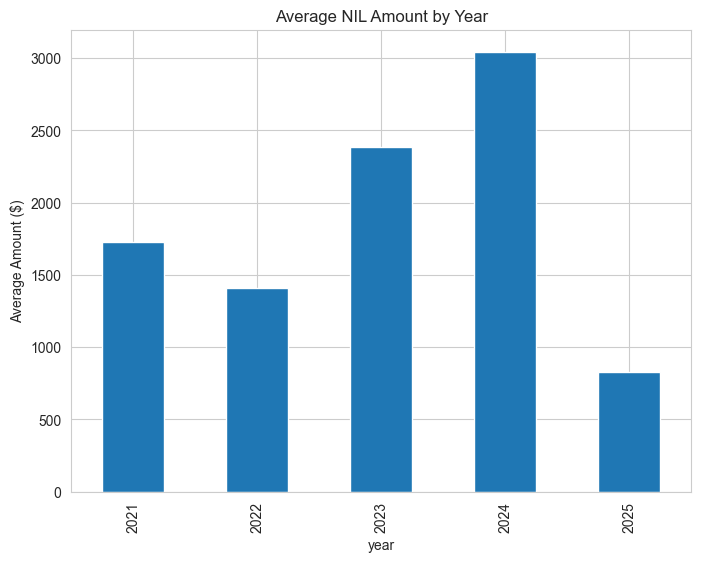

In [ ]:
# Avg amount by year
year_avg = df.groupby('year')['avg_transaction_value'].mean()
year_avg.plot(kind='bar', figsize=(6, 4), title='Average NIL Amount by Year')
plt.ylabel('Average Amount ($)')
plt.show()

**Justification:** School trends show elite programs drive higher values, teaching us that institutional factors must be controlled in models.

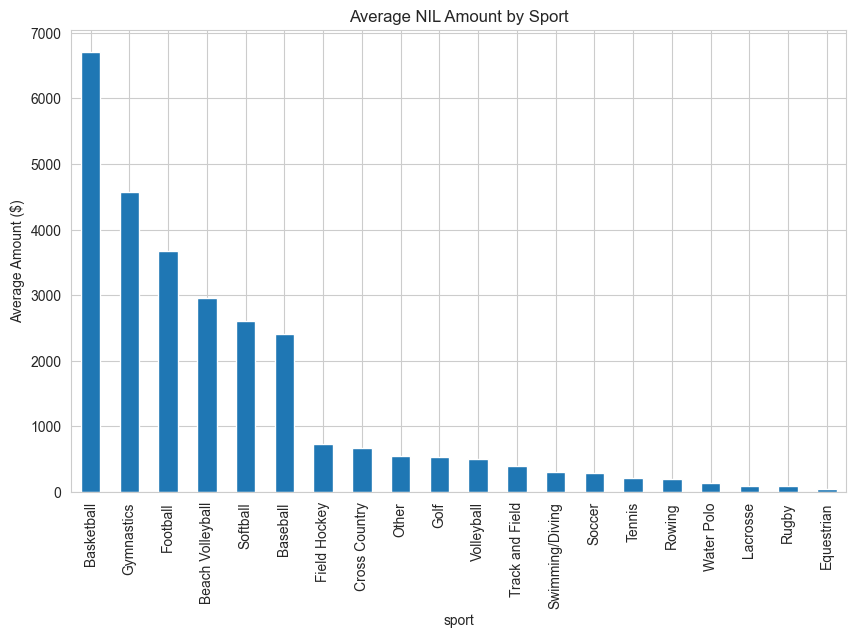

In [34]:
# Avg amount by sport
sport_avg = df.groupby('sport')['avg_transaction_value'].mean().sort_values(ascending=False)
sport_avg.plot(kind='bar', title='Average NIL Amount by Sport')
plt.ylabel('Average Amount ($)')
plt.show()

**Justification:** Year trends indicate market growth, teaching us that temporal effects may influence deal values over time.

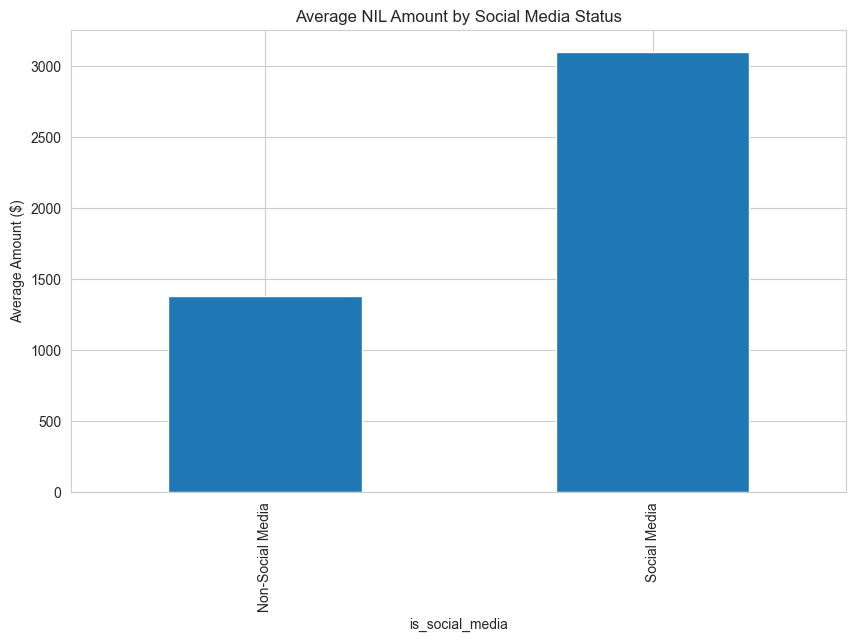

In [35]:
# Avg amount by social media
sm_avg = df.groupby('is_social_media')['avg_transaction_value'].mean()
sm_avg.plot(kind='bar', title='Average NIL Amount by Social Media Status')
plt.ylabel('Average Amount ($)')
plt.xticks([0,1], ['Non-Social Media', 'Social Media'])
plt.show()

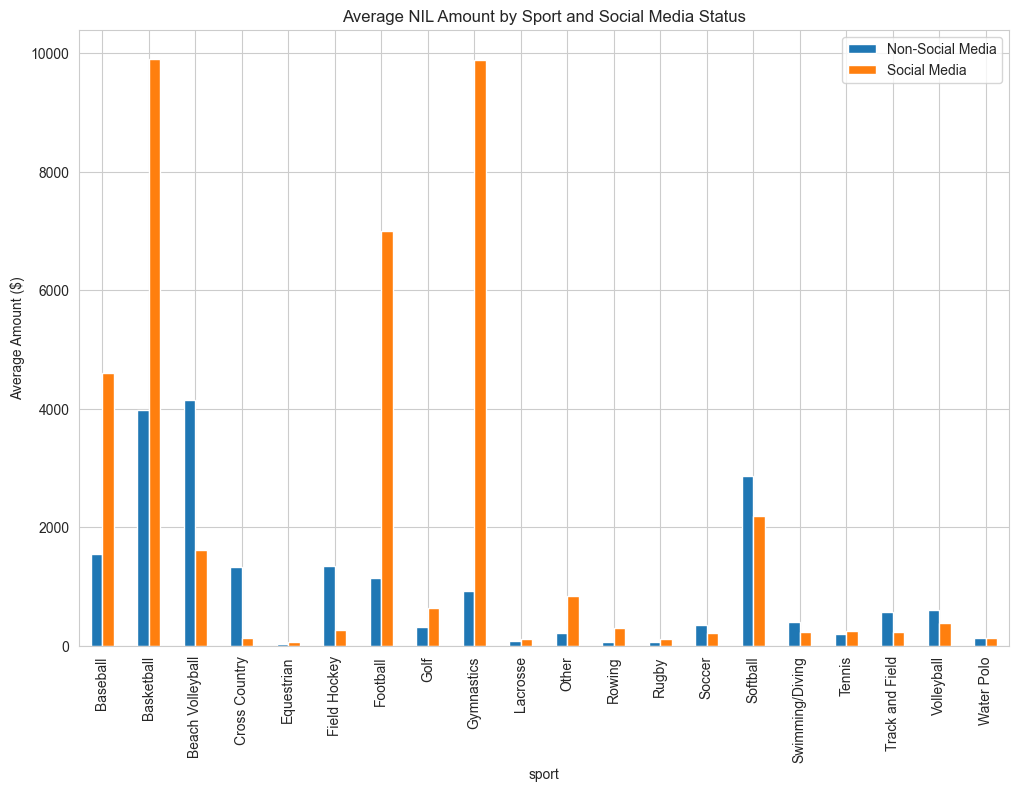

In [36]:
# Avg amount by sport and social media (to check heterogeneity/Simpson's Paradox)
sport_sm_avg = df.groupby(['sport', 'is_social_media'])['avg_transaction_value'].mean().unstack(fill_value=0)
sport_sm_avg.plot(kind='bar', figsize=(12, 8), title='Average NIL Amount by Sport and Social Media Status')
plt.ylabel('Average Amount ($)')
plt.legend(['Non-Social Media', 'Social Media'])
plt.show()

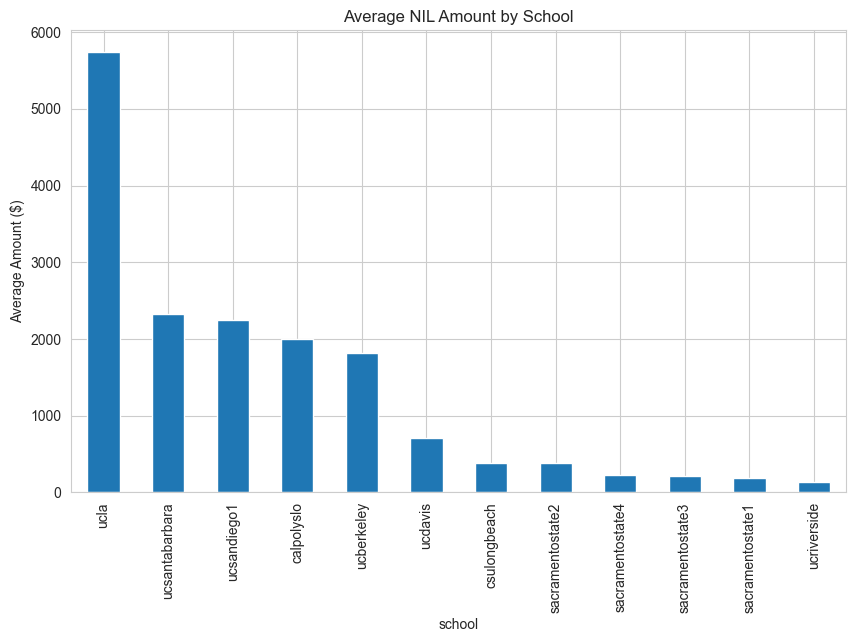

In [37]:
# Avg amount by school
school_avg = df.groupby('school')['avg_transaction_value'].mean().sort_values(ascending=False)
school_avg.plot(kind='bar', title='Average NIL Amount by School')
plt.ylabel('Average Amount ($)')
plt.show()

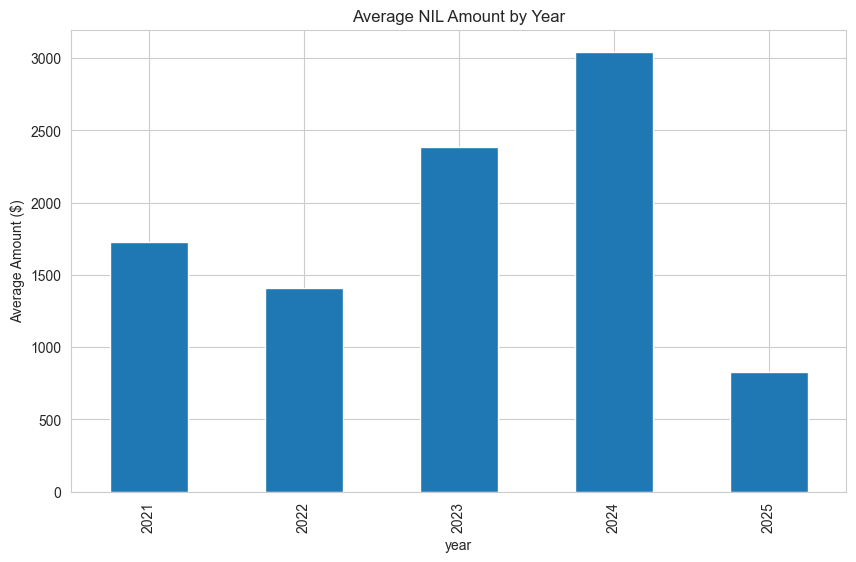

In [38]:
# Avg amount by year
year_avg = df.groupby('year')['avg_transaction_value'].mean().sort_index()
year_avg.plot(kind='bar', title='Average NIL Amount by Year')
plt.ylabel('Average Amount ($)')
plt.show()

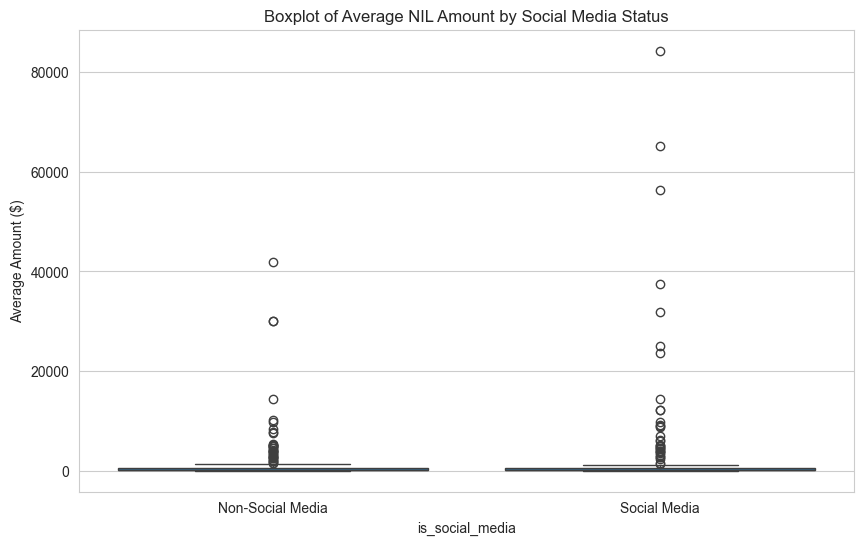

In [39]:
# Boxplot for avg_transaction_value by is_social_media
sns.boxplot(x='is_social_media', y='avg_transaction_value', data=df)
plt.title('Boxplot of Average NIL Amount by Social Media Status')
plt.xticks([0,1], ['Non-Social Media', 'Social Media'])
plt.ylabel('Average Amount ($)')
plt.show()

### Statistical Considerations
- **Data Sparsity**: With 271 groups, correlations are exploratory; statistical significance may be limited.
- **Measurement Error**: In-kind deals and under-reporting introduce noise.
- **Next Steps**: Proceed to regression analysis controlling for confounders (sport, school) to quantify social media's true effect.

## Conclusion

This EDA has provided a comprehensive understanding of the NIL dataset, revealing key characteristics, expectations, and correlations. The analysis highlights the importance of controlling for confounding variables like sport and school in future regression models to accurately estimate the effect of social media on deal values. Key learnings include the prevalence of reporting gaps, measurement challenges with in-kind deals, and the risk of Simpson's Paradox. The cleaned dataset is now ready for advanced statistical modeling to quantify causal relationships.